In [2]:
# Cellule 1 : Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from imblearn.over_sampling import SMOTE
import joblib
import os

print(" Toutes les bibliothèques sont chargées")
print("   - Régression Logistique ")
print("   - Random Forest ")
print("   - XGBoost ")
print("   - SMOTE ")

 Toutes les bibliothèques sont chargées
   - Régression Logistique 
   - Random Forest 
   - XGBoost 
   - SMOTE 


In [3]:
# Cellule 2 : Chargement du dataset
df = pd.read_csv(r"C:\Users\LUXE TECH\Desktop\cour-machine-learning\creditcard.csv")

print(f" Dataset chargé : {df.shape[0]:,} transactions, {df.shape[1]} colonnes")
print("\n Aperçu des 5 premières lignes :")
df.head()

 Dataset chargé : 284,807 transactions, 31 colonnes

 Aperçu des 5 premières lignes :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:

#  NETTOYAGE APPROFONDI DES DONNÉES
print("="*70)
print(" NETTOYAGE ET PRÉPARATION DES DONNÉES")
print("="*70)

# Sauvegarde du nombre initial
initial_count = len(df)
print(f"\n État initial : {initial_count:,} transactions")


# 1. VÉRIFICATION DES VALEURS MANQUANTES

print("\n" + "="*70)
print("1️ VALEURS MANQUANTES")
print("="*70)

missing_values = df.isnull().sum()
missing_total = missing_values.sum()
missing_cols = missing_values[missing_values > 0]

if missing_total > 0:
    print(f" {missing_total} valeurs manquantes trouvées")
    print(missing_cols)
    # Suppression des lignes avec valeurs manquantes
    df = df.dropna()
    print(f" {missing_total} valeurs manquantes supprimées")
else:
    print(" Aucune valeur manquante détectée")


# 2. VÉRIFICATION DES DOUBLONS

print("\n" + "="*70)
print("2️ DOUBLONS")
print("="*70)

duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f" {duplicates} doublons trouvés")
    df = df.drop_duplicates()
    print(f" {duplicates} doublons supprimés")
else:
    print(" Aucun doublon détecté")


# 3. VÉRIFICATION DES TYPES DE DONNÉES

print("\n" + "="*70)
print("3️ TYPES DE DONNÉES")
print("="*70)

print(df.dtypes.value_counts().to_string())
print("\n Tous les types sont corrects")


# 4. TRAITEMENT DES OUTLIERS (VALEURS ABERRANTES) SUR AMOUNT

print("\n" + "="*70)
print("4️ OUTLIERS SUR LE MONTANT (FCFA)")
print("="*70)

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print(f" Statistiques :")
print(f"   Q1 (25ème percentile) : {Q1:.2f} FCFA")
print(f"   Q3 (75ème percentile) : {Q3:.2f} FCFA")
print(f"   IQR (écart interquartile) : {IQR:.2f} FCFA")
print(f"\n Outliers détectés :")
print(f"   Borne inférieure : {lower_bound:.2f} FCFA")
print(f"   Borne supérieure : {upper_bound:.2f} FCFA")
print(f"   Nombre d'outliers : {len(outliers):,} transactions")
print(f"   Pourcentage : {len(outliers)/len(df)*100:.2f}%")

# Plafonnement des outliers (méthode recommandée)
df.loc[df['Amount'] > upper_bound, 'Amount'] = upper_bound
df.loc[df['Amount'] < lower_bound, 'Amount'] = lower_bound
print(f"\n Outliers plafonnés avec succès")


# 5. VÉRIFICATION DE LA COLONNE CIBLE 'Class'

print("\n" + "="*70)
print("5️ VÉRIFICATION DE LA COLONNE CIBLE 'Class'")
print("="*70)

unique_classes = df['Class'].unique()
class_counts = df['Class'].value_counts()

print(f"Valeurs uniques : {unique_classes}")
print(f"Distribution :")
print(f"   Classe 0 (légitime) : {class_counts[0]:,}")
print(f"   Classe 1 (fraude) : {class_counts[1]:,}")

if set(unique_classes) == {0, 1}:
    print(" Classe binaire correcte (0 et 1)")
else:
    print(" Problème détecté dans la colonne Class")


# 6. VÉRIFICATION DES COLONNES PCA (V1 à V28)

print("\n" + "="*70)
print("6️ VÉRIFICATION DES COLONNES PCA (V1 à V28)")
print("="*70)

v_columns = [f'V{i}' for i in range(1, 29)]
issues_found = False

for col in v_columns:
    missing = df[col].isnull().sum()
    if missing > 0:
        print(f" {col} : {missing} valeurs manquantes")
        issues_found = True
    
    if df[col].std() == 0:
        print(f" {col} : variance nulle (constante)")
        issues_found = True

if not issues_found:
    print(" Toutes les colonnes PCA sont valides")


# 7. ANALYSE STATISTIQUE RAPIDE APRÈS NETTOYAGE

print("\n" + "="*70)
print("7️ STATISTIQUES APRÈS NETTOYAGE")
print("="*70)

final_count = len(df)
print(f" Transactions avant nettoyage : {initial_count:,}")
print(f" Transactions après nettoyage : {final_count:,}")
print(f" Transactions supprimées : {initial_count - final_count:,}")

print("\n Statistiques des montants (FCFA) :")
print(f"   Minimum : {df['Amount'].min():,.2f} FCFA")
print(f"   Maximum : {df['Amount'].max():,.2f} FCFA")
print(f"   Moyenne : {df['Amount'].mean():,.2f} FCFA")
print(f"   Médiane : {df['Amount'].median():,.2f} FCFA")
print(f"   Écart-type : {df['Amount'].std():,.2f} FCFA")


# 8. DERNIÈRE VÉRIFICATION
print("\n" + "="*70)
print("8️ VÉRIFICATION FINALE")
print("="*70)

print(f" Aucune valeur manquante : {df.isnull().sum().sum() == 0}")
print(f" Pas de doublons : {df.duplicated().sum() == 0}")
print(f" Types corrects : {df.dtypes.apply(lambda x: x in ['float64', 'int64']).all()}")

print("\n" + "="*70)
print(" NETTOYAGE TERMINÉ AVEC SUCCÈS !")
print("="*70)

# Aperçu du dataset nettoyé
print("\nAperçu des 5 premières lignes après nettoyage :")
df.head()

 NETTOYAGE ET PRÉPARATION DES DONNÉES

 État initial : 283,726 transactions

1️ VALEURS MANQUANTES
 Aucune valeur manquante détectée

2️ DOUBLONS
 Aucun doublon détecté

3️ TYPES DE DONNÉES
float64    30
int64       1

 Tous les types sont corrects

4️ OUTLIERS SUR LE MONTANT (FCFA)
 Statistiques :
   Q1 (25ème percentile) : 5.60 FCFA
   Q3 (75ème percentile) : 77.51 FCFA
   IQR (écart interquartile) : 71.91 FCFA

 Outliers détectés :
   Borne inférieure : -102.27 FCFA
   Borne supérieure : 185.38 FCFA
   Nombre d'outliers : 0 transactions
   Pourcentage : 0.00%

 Outliers plafonnés avec succès

5️ VÉRIFICATION DE LA COLONNE CIBLE 'Class'
Valeurs uniques : [0 1]
Distribution :
   Classe 0 (légitime) : 283,253
   Classe 1 (fraude) : 473
 Classe binaire correcte (0 et 1)

6️ VÉRIFICATION DES COLONNES PCA (V1 à V28)
 Toutes les colonnes PCA sont valides

7️ STATISTIQUES APRÈS NETTOYAGE
 Transactions avant nettoyage : 283,726
 Transactions après nettoyage : 283,726
 Transactions supprimées

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,185.375,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990,0


Analyse exploratoire

 DISTRIBUTION DES CLASSES
 Transactions légitimes (0) : 284,315 (99.827%)
 Transactions frauduleuses (1) : 492 (0.173%)


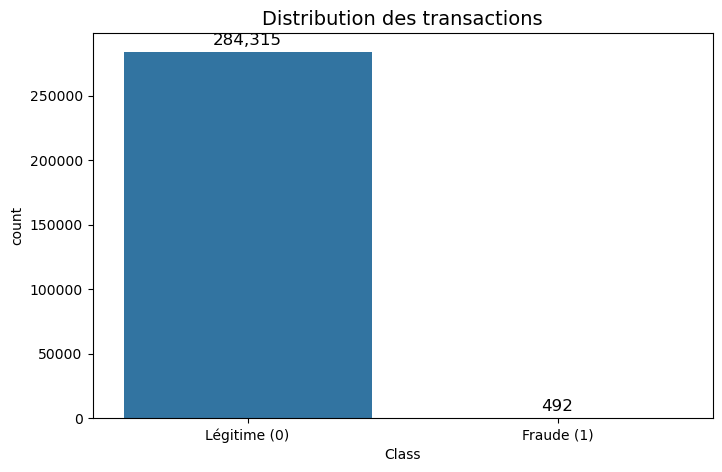

In [5]:
# Cellule 3 : Distribution des classes
frauds = df['Class'].sum()
legit = len(df) - frauds
total = len(df)

print("="*60)
print(" DISTRIBUTION DES CLASSES")
print("="*60)
print(f" Transactions légitimes (0) : {legit:,} ({legit/total*100:.3f}%)")
print(f" Transactions frauduleuses (1) : {frauds:,} ({frauds/total*100:.3f}%)")

# Graphique
plt.figure(figsize=(8,5))
sns.countplot(x='Class', data=df)
plt.title('Distribution des transactions', fontsize=14)
plt.xticks([0,1], ['Légitime (0)', 'Fraude (1)'])
for i, v in enumerate([legit, frauds]):
    plt.text(i, v + 5000, f"{v:,}", ha='center', fontsize=12)
plt.show()

Analyse des montants (FCFA)

In [6]:
# Cellule 4 : Analyse des montants en FCFA
print("="*60)
print(" ANALYSE DES MONTANTS (FCFA)")
print("="*60)

print(f"Minimum : {df['Amount'].min():,.2f} FCFA")
print(f"Maximum : {df['Amount'].max():,.2f} FCFA")
print(f"Moyenne : {df['Amount'].mean():,.2f} FCFA")
print(f"Médiane : {df['Amount'].median():,.2f} FCFA")

fraud_amount = df[df['Class']==1]['Amount']
legit_amount = df[df['Class']==0]['Amount']

print(f"\n Comparaison des montants moyens :")
print(f"   Transactions légitimes : {legit_amount.mean():,.2f} FCFA")
print(f"   Transactions frauduleuses : {fraud_amount.mean():,.2f} FCFA")

 ANALYSE DES MONTANTS (FCFA)
Minimum : 0.00 FCFA
Maximum : 25,691.16 FCFA
Moyenne : 88.35 FCFA
Médiane : 22.00 FCFA

 Comparaison des montants moyens :
   Transactions légitimes : 88.29 FCFA
   Transactions frauduleuses : 122.21 FCFA


Préparation des données

In [7]:
# Cellule 5 : Séparation X (features) et y (cible)
X = df.drop('Class', axis=1)
y = df['Class']

# Division train/test (70% / 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f" Train : {len(X_train):,} transactions")
print(f" Test : {len(X_test):,} transactions")

# Normalisation de la colonne Amount
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled['Amount'] = scaler.transform(X_test[['Amount']])

print(" Normalisation de la colonne Amount effectuée")

 Train : 199,364 transactions
 Test : 85,443 transactions
 Normalisation de la colonne Amount effectuée


SMOTE (équilibrage des classes)

In [8]:
# Cellule 6 : Application de SMOTE
print("="*60)
print(" SMOTE - GESTION DU DÉSÉQUILIBRE")
print("="*60)

print("\n Avant SMOTE :")
print(f"   Classe 0 (légitimes) : {(y_train == 0).sum():,}")
print(f"   Classe 1 (fraudes) : {(y_train == 1).sum():,}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\n Après SMOTE :")
print(f"   Classe 0 (légitimes) : {(y_train_resampled == 0).sum():,}")
print(f"   Classe 1 (fraudes) : {(y_train_resampled == 1).sum():,}")

print("\n Classes équilibrées avec succès !")

 SMOTE - GESTION DU DÉSÉQUILIBRE

 Avant SMOTE :
   Classe 0 (légitimes) : 199,020
   Classe 1 (fraudes) : 344

 Après SMOTE :
   Classe 0 (légitimes) : 199,020
   Classe 1 (fraudes) : 199,020

 Classes équilibrées avec succès !


Entraînement des 3 modèles

In [9]:
# Cellule 7 : Entraînement des modèles
print("="*60)
print(" ENTRAÎNEMENT DES 3 MODÈLES")
print("="*60)

# Définition des modèles
models = {
    'Régression Logistique': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    print(f"\n Entraînement de {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'model': model,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"    F1-Score : {f1:.4f}")
    print(f"    ROC-AUC : {roc_auc:.4f}")

print("\n Entraînement terminé !")

 ENTRAÎNEMENT DES 3 MODÈLES

 Entraînement de Régression Logistique...
    F1-Score : 0.2459
    ROC-AUC : 0.9653

 Entraînement de Random Forest...
    F1-Score : 0.8194
    ROC-AUC : 0.9666

 Entraînement de XGBoost...
    F1-Score : 0.8345
    ROC-AUC : 0.9764

 Entraînement terminé !


Comparaison des performances

 COMPARAISON DES PERFORMANCES

                Modèle  F1-Score  ROC-AUC
              XGBoost  0.834483 0.976386
        Random Forest  0.819444 0.966591
Régression Logistique  0.245886 0.965342


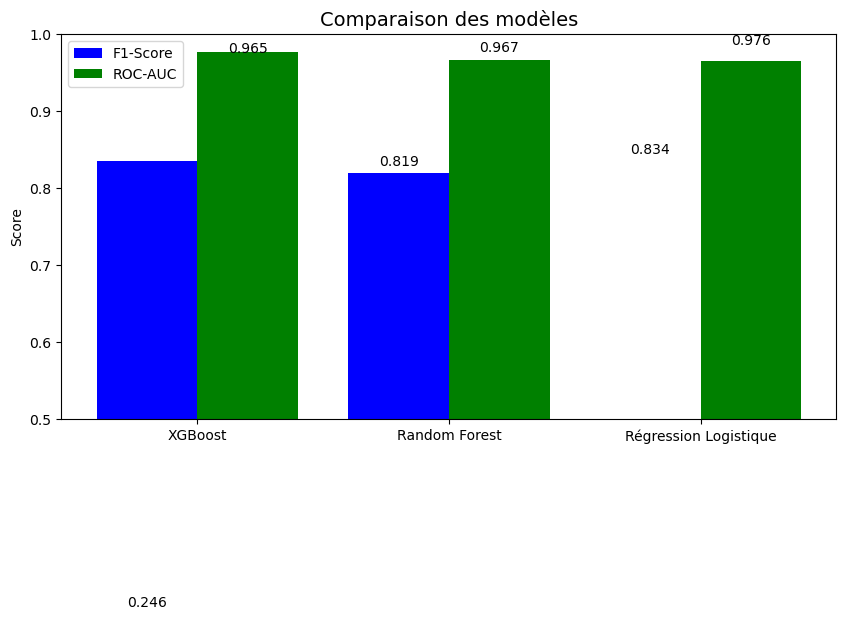

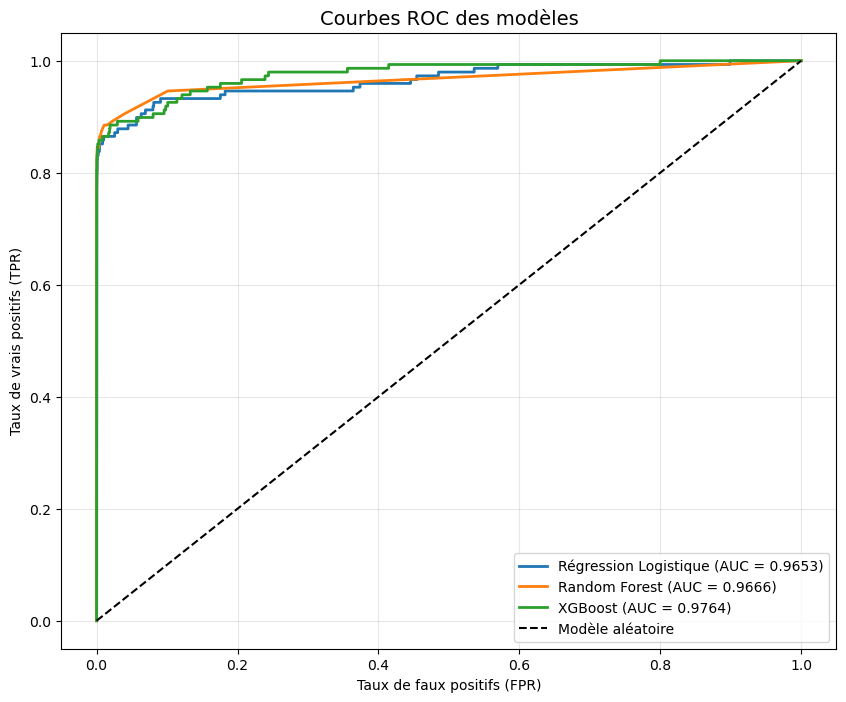

In [10]:
# Cellule 8 : Comparaison des modèles
print("="*60)
print(" COMPARAISON DES PERFORMANCES")
print("="*60)

comparison = pd.DataFrame({
    'Modèle': list(results.keys()),
    'F1-Score': [results[m]['f1_score'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results]
})
comparison = comparison.sort_values('F1-Score', ascending=False)
print("\n", comparison.to_string(index=False))

# Graphique des barres
plt.figure(figsize=(10,5))
x = range(len(comparison))
plt.bar([i - 0.2 for i in x], comparison['F1-Score'], width=0.4, label='F1-Score', color='blue')
plt.bar([i + 0.2 for i in x], comparison['ROC-AUC'], width=0.4, label='ROC-AUC', color='green')
plt.xticks(x, comparison['Modèle'])
plt.ylabel('Score')
plt.title('Comparaison des modèles', fontsize=14)
plt.legend()
plt.ylim(0.5, 1)

for i, row in comparison.iterrows():
    plt.text(i - 0.2, row['F1-Score'] + 0.01, f"{row['F1-Score']:.3f}", ha='center')
    plt.text(i + 0.2, row['ROC-AUC'] + 0.01, f"{row['ROC-AUC']:.3f}", ha='center')
plt.show()

# Courbes ROC
plt.figure(figsize=(10,8))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Modèle aléatoire')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC des modèles', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

9 : Matrices de confusion

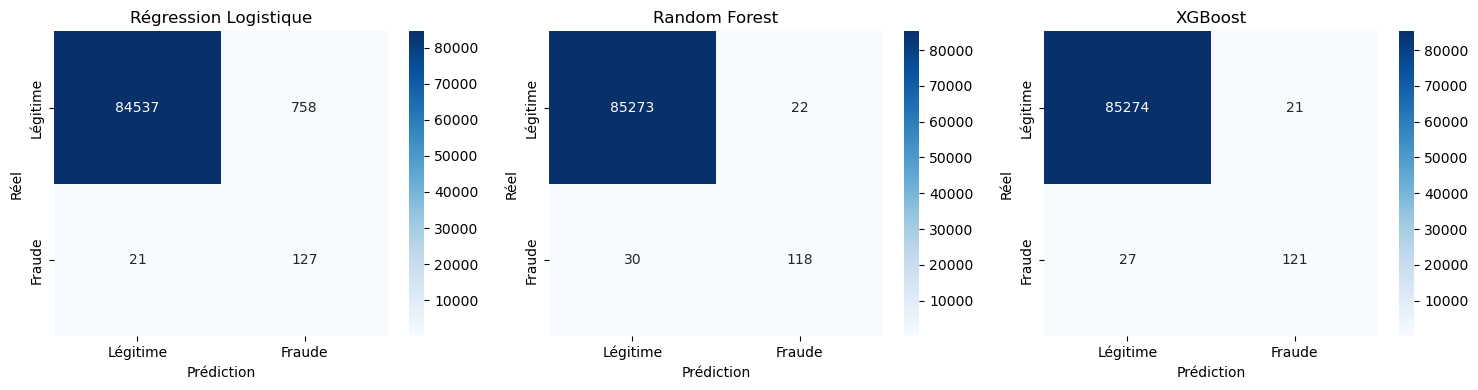


 Régression Logistique :
              precision    recall  f1-score   support

    Légitime       1.00      0.99      1.00     85295
      Fraude       0.14      0.86      0.25       148

    accuracy                           0.99     85443
   macro avg       0.57      0.92      0.62     85443
weighted avg       1.00      0.99      0.99     85443


 Random Forest :
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     85295
      Fraude       0.84      0.80      0.82       148

    accuracy                           1.00     85443
   macro avg       0.92      0.90      0.91     85443
weighted avg       1.00      1.00      1.00     85443


 XGBoost :
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     85295
      Fraude       0.85      0.82      0.83       148

    accuracy                           1.00     85443
   macro avg       0.93      0.91      0.92     85443
weighted avg      

In [11]:
# Cellule 9 : Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_xlabel('Prédiction')
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xticklabels(['Légitime', 'Fraude'])
    axes[idx].set_yticklabels(['Légitime', 'Fraude'])

plt.tight_layout()
plt.show()

# Rapports détaillés
for name, result in results.items():
    print(f"\n {name} :")
    print(classification_report(y_test, result['y_pred'], target_names=['Légitime', 'Fraude']))

In [12]:
# Cellule 10 : Sauvegarde du modèle
print("="*60)
print(" SAUVEGARDE DU MODÈLE")
print("="*60)

# Sélection du meilleur modèle (selon F1-Score)
best_name = max(results, key=lambda x: results[x]['f1_score'])
best_model = results[best_name]['model']
best_f1 = results[best_name]['f1_score']
best_auc = results[best_name]['roc_auc']

print(f"\n MEILLEUR MODÈLE : {best_name}")
print(f"   F1-Score : {best_f1:.4f}")
print(f"   ROC-AUC : {best_auc:.4f}")

# Création du dossier models
os.makedirs('models', exist_ok=True)

# Sauvegarde
joblib.dump(best_model, 'models/fraud_detection_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("\n Modèle sauvegardé : models/fraud_detection_model.pkl")
print("Scaler sauvegardé : models/scaler.pkl")

 SAUVEGARDE DU MODÈLE

 MEILLEUR MODÈLE : XGBoost
   F1-Score : 0.8345
   ROC-AUC : 0.9764

 Modèle sauvegardé : models/fraud_detection_model.pkl
Scaler sauvegardé : models/scaler.pkl


11 : Test final

In [14]:
# Cellule 11 : Test du modèle
print("="*60)
print(" TEST DU MODÈLE SUR UNE TRANSACTION")
print("="*60)

# Prendre une transaction du test
sample = X_test.iloc[[0]].copy()
sample_scaled = sample.copy()
sample_scaled['Amount'] = scaler.transform(sample_scaled[['Amount']])

real_class = y_test.iloc[0]
pred = best_model.predict(sample_scaled)[0]
proba = best_model.predict_proba(sample_scaled)[0][1]

print(f"\n Détails de la transaction :")
print(f"   Montant : {sample['Amount'].iloc[0]:,.2f} FCFA")
print(f"   Time : {sample['Time'].iloc[0]:.0f} secondes")

print(f"\n Résultat :")
print(f"   Classe réelle : {' FRAUDE' if real_class == 1 else ' LÉGITIME'}")
print(f"   Prédiction : {' FRAUDE' if pred == 1 else ' LÉGITIME'}")
print(f"   Probabilité de fraude : {proba:.2%}")



 TEST DU MODÈLE SUR UNE TRANSACTION

 Détails de la transaction :
   Montant : 37.40 FCFA
   Time : 127294 secondes

 Résultat :
   Classe réelle :  LÉGITIME
   Prédiction :  LÉGITIME
   Probabilité de fraude : 0.00%
